# PhysioNet EEG Motor Movement/Imagery — Exploration

This notebook explores subject 2 from the PhysioNet EEG Motor Movement/Imagery dataset.

It has two parts:
1. **Alpha rhythm** — comparing eyes-open vs eyes-closed baseline runs (the EEG "hello world").
2. **Motor imagery** — loading the imagined left/right hand runs and epoching them into labeled trials.

Run top-to-bottom from a fresh kernel.

In [26]:
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
import mne
from mne.datasets import eegbci
from pathlib import Path

print('MNE version:', mne.__version__)

MNE version: 1.12.1


In [27]:
# Where the dataset lives, and which subject we analyze
data_dir = Path.home() / "projects" / "bci" / "data" / "raw"
data_dir.mkdir(parents=True, exist_ok=True)
subject = 2

# Standard montage (electrode 3D positions) reused throughout the notebook
montage = mne.channels.make_standard_montage("standard_1005")
print("Subject:", subject)
print("Data dir:", data_dir)

Subject: 2
Data dir: /home/beecki303/projects/bci/data/raw


## 2. Alpha rhythm: eyes-open (run 1) vs eyes-closed (run 2)

Baseline runs 1 and 2 are resting recordings. With eyes **closed**, a strong ~10 Hz alpha rhythm appears over the occipital cortex. We load both runs and compare their power spectra at O1/O2/Oz.

In [28]:
# Download + load the two baseline runs (1 = eyes open, 2 = eyes closed)
baseline_runs = [1, 2]
baseline_fnames = eegbci.load_data(subjects=[subject], runs=baseline_runs, path=str(data_dir))

# Eyes OPEN = run 1
raw_eyes_open = mne.io.read_raw_edf(baseline_fnames[0], preload=True)
eegbci.standardize(raw_eyes_open)
raw_eyes_open.set_montage(montage)

# Eyes CLOSED = run 2
raw_eyes_closed = mne.io.read_raw_edf(baseline_fnames[1], preload=True)
eegbci.standardize(raw_eyes_closed)
raw_eyes_closed.set_montage(montage)

print("Eyes open duration:", round(raw_eyes_open.times[-1], 1), "s")
print("Eyes closed duration:", round(raw_eyes_closed.times[-1], 1), "s")

Extracting EDF parameters from /home/beecki303/projects/bci/data/raw/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Extracting EDF parameters from /home/beecki303/projects/bci/data/raw/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R02.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Eyes open duration: 61.0 s
Eyes closed duration: 61.0 s


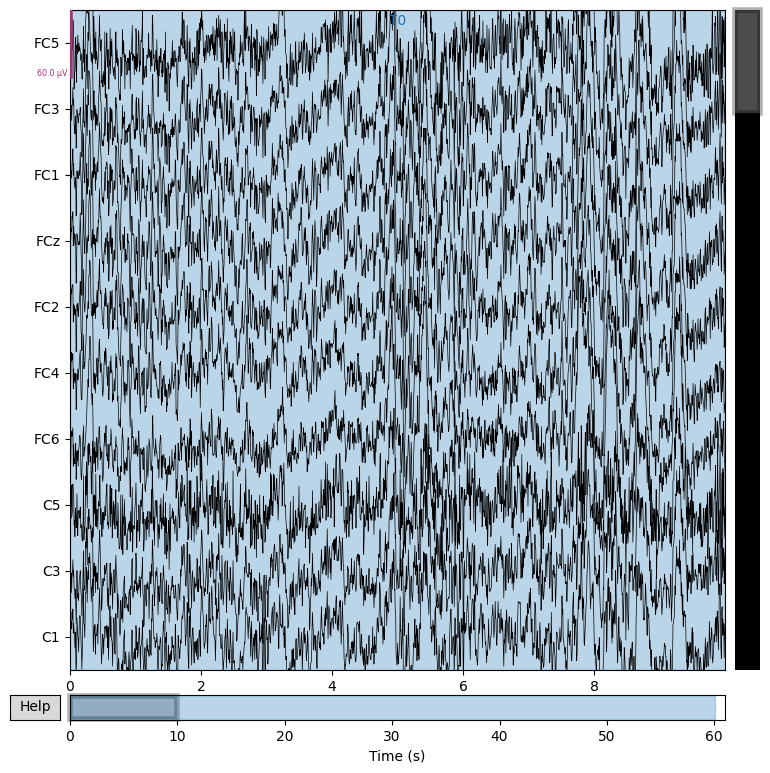

In [29]:
# Quick look at raw eyes-open EEG (first 10 seconds, 10 channels)
%matplotlib inline
raw_eyes_open.plot(duration=10, n_channels=10, scalings="auto", show=True);

Effective window size : 12.800 (s)
Effective window size : 12.800 (s)


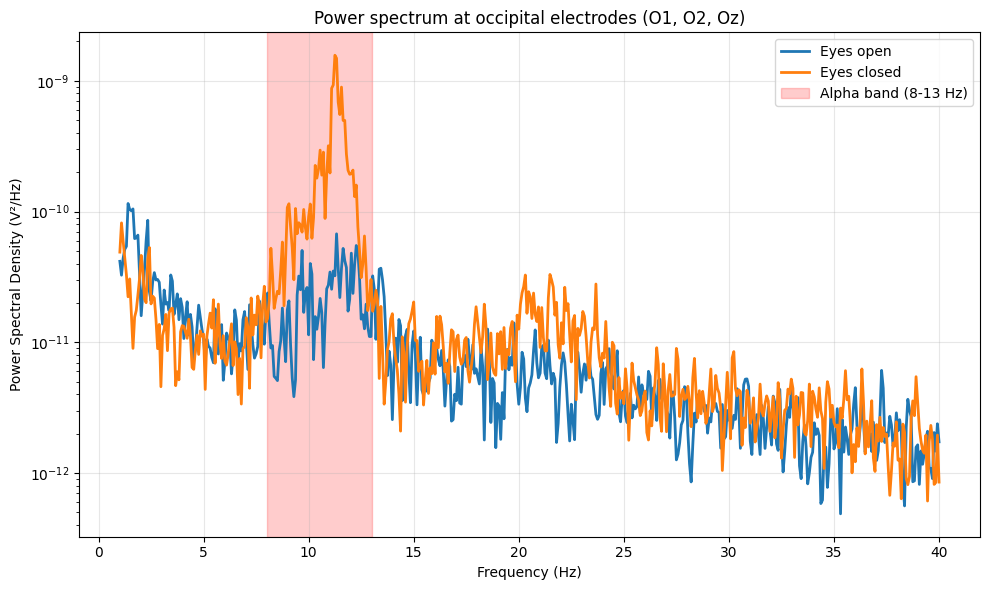

In [30]:
# Compare power spectra at occipital channels: alpha should spike when eyes are closed
occipital_channels = ["O1", "O2", "Oz"]

fig, ax = plt.subplots(figsize=(10, 6))

psd_open = raw_eyes_open.compute_psd(fmin=1, fmax=40, picks=occipital_channels)
psd_closed = raw_eyes_closed.compute_psd(fmin=1, fmax=40, picks=occipital_channels)

freqs = psd_open.freqs
power_open = psd_open.get_data().mean(axis=0)
power_closed = psd_closed.get_data().mean(axis=0)

ax.semilogy(freqs, power_open, label="Eyes open", linewidth=2)
ax.semilogy(freqs, power_closed, label="Eyes closed", linewidth=2)
ax.axvspan(8, 13, alpha=0.2, color="red", label="Alpha band (8-13 Hz)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Spectral Density (V²/Hz)")
ax.set_title("Power spectrum at occipital electrodes (O1, O2, Oz)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Motor imagery: runs 4, 8, 12 (imagined left vs right fist)

These three runs are the "imagine left vs right fist" task. Annotations mark each cue:
- **T0** = rest
- **T1** = imagined **left** fist
- **T2** = imagined **right** fist

We load and concatenate the three runs, clean them, and extract the events.

In [31]:
# E7: Load + concatenate the three motor imagery runs
imagery_runs = [4, 8, 12]
imagery_fnames = eegbci.load_data(subjects=[subject], runs=imagery_runs, path=str(data_dir))

raws = [mne.io.read_raw_edf(f, preload=True) for f in imagery_fnames]
raw_mi = mne.concatenate_raws(raws)

eegbci.standardize(raw_mi)
raw_mi.set_montage(montage)

events, event_id = mne.events_from_annotations(raw_mi)

print("Event ID mapping:", event_id)
print("Total number of events:", len(events))
print(f"Duration: {raw_mi.times[-1]:.1f} seconds (expect ~369)")
print(f"First 10 channels: {raw_mi.ch_names[:10]}")

Extracting EDF parameters from /home/beecki303/projects/bci/data/raw/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from /home/beecki303/projects/bci/data/raw/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from /home/beecki303/projects/bci/data/raw/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Event ID mapping: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
Total number of events: 90
Duration: 369.0 seconds (expect ~369)
First 10 channels: ['FC5', 'FC3', 'FC1', 'FC

In [32]:
# E8: Epoch into labeled left/right trials
# T1 = imagined LEFT fist, T2 = imagined RIGHT fist
epoch_event_id = {"T1": event_id["T1"], "T2": event_id["T2"]}

# Window 0.5s-2.5s after each cue: skip the cue-reaction transient,
# capture the strongest motor-imagery period
tmin, tmax = 0.5, 2.5

epochs = mne.Epochs(
    raw_mi, events,
    event_id=epoch_event_id,
    tmin=tmin, tmax=tmax,
    baseline=None,
    picks="eeg",
    preload=True,
)

print(epochs)
print("\nData shape (trials, channels, samples):", epochs.get_data().shape)

Not setting metadata
45 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 45 events and 321 original time points ...
0 bad epochs dropped
<Epochs | 45 events (all good), 0.5 – 2.5 s (baseline off), ~7.1 MiB, data loaded,
 'T1': 23
 'T2': 22>

Data shape (trials, channels, samples): (45, 64, 321)
